🔄 Preparing data...
🔢 Number of folds for cross-validation: 5
🚀 Training models to get feature importances...
🏆 Top 7 important features: ['call_history_squared', '12m_call_history', 'calls_per_tenure', 'premium_to_calls_ratio', 'tenure_at_snapshot', 'premium_tenure_interaction', 'ann_prm_amt']
📊 Performing cross-validation with top 7 features...
⏳ Fold 1...
⏳ Fold 2...
⏳ Fold 3...
⏳ Fold 4...
⏳ Fold 5...
⌛ Cross-validation completed in 23.53 seconds.

📈 Cross-validation RMSE scores with top 7 features: [36.021638061724325, 35.852333811004115, 36.24653317254032, 35.78786877582661, 35.81658795827111]
📊 Mean RMSE with top 7 features: 35.944992355873296
📉 Std RMSE with top 7 features: 0.17120896180349857


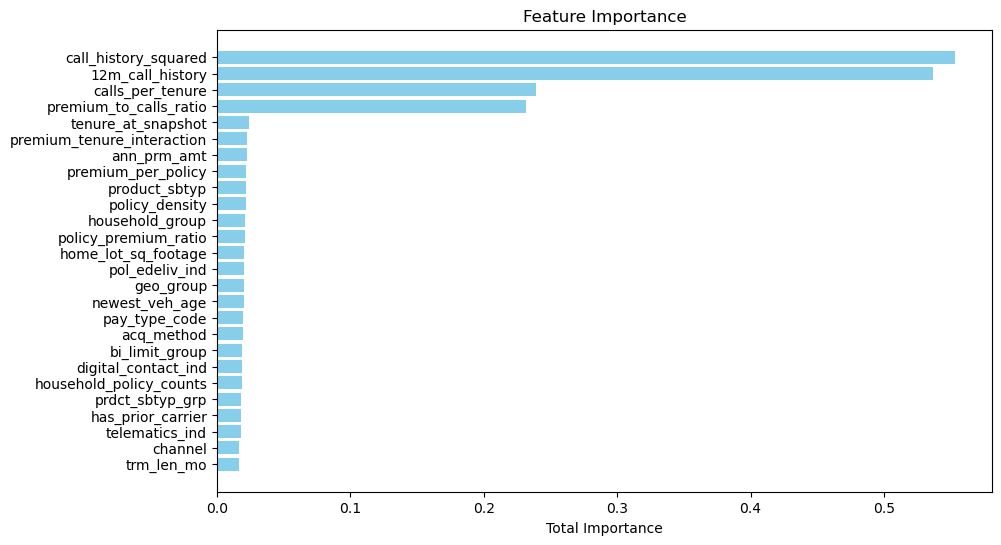

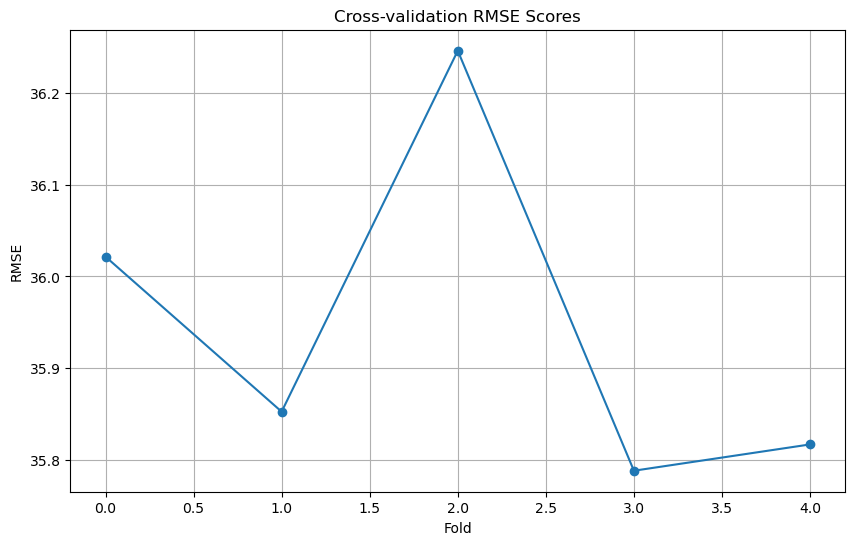

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from math import sqrt
import time
import matplotlib.pyplot as plt

# Read the data
train = pd.read_csv('train_data.csv')
test = pd.read_csv('test_data.csv')

# Feature Engineering
def prepare_data(df):
    data = df.copy()
    
    # Handle missing values
    for col in data.columns:
        if data[col].dtype in ['int64', 'float64']:
            data[col] = data[col].fillna(data[col].median())
        else:
            data[col] = data[col].fillna(data[col].mode()[0])

    # Label encode categorical columns
    le = LabelEncoder()
    categorical_cols = ['acq_method', 'bi_limit_group', 'channel', 'geo_group',
                       'household_group', 'pay_type_code', 'prdct_sbtyp_grp', 'product_sbtyp']

    for col in categorical_cols:
        data[col] = le.fit_transform(data[col].astype(str))

    # Feature engineering
    data['premium_per_policy'] = np.where(
        data['household_policy_counts'] != 0,
        data['ann_prm_amt'] / data['household_policy_counts'],
        0
    )
    data['calls_per_tenure'] = data['12m_call_history'] / (data['tenure_at_snapshot'] + 1)
    data['premium_to_calls_ratio'] = np.where(
        data['12m_call_history'] != 0,
        data['ann_prm_amt'] / data['12m_call_history'],
        0
    )
    data['policy_density'] = data['household_policy_counts'] / (data['tenure_at_snapshot'] + 1)
    
    # Additional features for two-stage model
    data['premium_tenure_interaction'] = data['ann_prm_amt'] * data['tenure_at_snapshot']
    data['policy_premium_ratio'] = data['household_policy_counts'] * data['ann_prm_amt']
    data['call_history_squared'] = data['12m_call_history'] ** 2
    
    return data

# Prepare the data
print("🔄 Preparing data...")
train_processed = prepare_data(train)
test_processed = prepare_data(test)

# Create binary target for first stage
train_processed['is_zero'] = (train_processed['call_counts'] == 0).astype(int)

# Split features and target
X = train_processed.drop(['id', 'call_counts', 'is_zero'], axis=1)
y_binary = train_processed['is_zero']
y_regression = train_processed['call_counts']

# Define cross-validation strategy
n_folds = 5
print(f"🔢 Number of folds for cross-validation: {n_folds}")
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Parameters for binary classification (with regularization)
binary_params = {
    'objective': 'binary:logistic',
    'max_depth': 2,
    'learning_rate': 0.007,
    'n_estimators': 3000,
    'subsample': 0.50,
    'colsample_bytree': 0.50,
    'alpha': 0.01,      
    'lambda': 10.0,       
    'gamma': 0.5         
}

# Parameters for regression model (with regularization)
regression_params = {
    'objective': 'reg:squarederror',
    'max_depth': 2,
    'learning_rate': 0.001,
    'n_estimators': 6000,
    'subsample': 0.50,
    'colsample_bytree': 0.50,
    'alpha': 0.01,      # L1 regularization
    'lambda': 10.0,       # L2 regularization
    'gamma': 0.5         # Minimum loss reduction
}

# Initialize models
binary_model = xgb.XGBClassifier(**binary_params)
regression_model = xgb.XGBRegressor(**regression_params)

# Train both models on the full dataset to get feature importances
print("🚀 Training models to get feature importances...")
binary_model.fit(X, y_binary)
regression_model.fit(X, y_regression)

# Get feature importance from both models
binary_importance = pd.DataFrame({
    'feature': X.columns,
    'binary_importance': binary_model.feature_importances_
})

regression_importance = pd.DataFrame({
    'feature': X.columns,
    'regression_importance': regression_model.feature_importances_
})

# Combine feature importance
importance = binary_importance.merge(regression_importance, on='feature')
importance['total_importance'] = importance['binary_importance'] + importance['regression_importance']
importance = importance.sort_values('total_importance', ascending=False)

# Select top 7 features
top_7_features = importance['feature'].head(7).tolist()
print(f"🏆 Top 7 important features: {top_7_features}")

# Update the feature set to only the top 7 features
X_top7 = X[top_7_features]
test_top7 = test_processed[top_7_features]

# Re-run the cross-validation using only the top 7 features
cv_rmse_scores_top7 = []
cv_predictions_top7 = np.zeros(len(test_processed))

print("📊 Performing cross-validation with top 7 features...")
start_time = time.time()
for fold, (train_idx, val_idx) in enumerate(kf.split(X_top7), 1):
    print(f"⏳ Fold {fold}...")
    
    X_train, X_val = X_top7.iloc[train_idx], X_top7.iloc[val_idx]
    y_binary_train, y_binary_val = y_binary.iloc[train_idx], y_binary.iloc[val_idx]
    y_regression_train, y_regression_val = y_regression.iloc[train_idx], y_regression.iloc[val_idx]
    
    # Train binary model
    binary_model.fit(X_train, y_binary_train)
    
    # Get binary predictions
    binary_pred_val = binary_model.predict_proba(X_val)[:, 1]
    binary_pred_test = binary_model.predict_proba(test_top7)[:, 1]
    
    # Train regression model on non-zero samples
    non_zero_mask_train = (y_regression_train > 0)
    X_train_nonzero = X_train[non_zero_mask_train]
    y_regression_train_nonzero = y_regression_train[non_zero_mask_train]
    
    regression_model.fit(X_train_nonzero, y_regression_train_nonzero)
    
    # Make regression predictions
    regression_pred_val = regression_model.predict(X_val)
    regression_pred_test = regression_model.predict(test_top7)
    
    # Combine predictions
    final_pred_val = (1 - binary_pred_val) * regression_pred_val
    final_pred_test = (1 - binary_pred_test) * regression_pred_test
    
    # Calculate RMSE for this fold
    fold_rmse_top7 = sqrt(mean_squared_error(y_regression_val, final_pred_val))
    cv_rmse_scores_top7.append(fold_rmse_top7)
    
    # Add to test predictions
    cv_predictions_top7 += final_pred_test / n_folds

end_time = time.time()
total_time = end_time - start_time
print(f"⌛ Cross-validation completed in {total_time:.2f} seconds.")

print("\n📈 Cross-validation RMSE scores with top 7 features:", cv_rmse_scores_top7)
print("📊 Mean RMSE with top 7 features:", np.mean(cv_rmse_scores_top7))
print("📉 Std RMSE with top 7 features:", np.std(cv_rmse_scores_top7))

# Create a submission file using top 7 feature model
submission_top7 = pd.DataFrame({
    'id': test_processed['id'],
    'Predict': cv_predictions_top7
})

# Ensure predictions are non-negative
submission_top7['Predict'] = np.maximum(0, submission_top7['Predict'])

submission_top7.to_csv('submission_top7_features.csv', index=False)

# Plotting feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance['feature'], importance['total_importance'], color='skyblue')
plt.xlabel('Total Importance')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()

# Plotting CV RMSE scores
plt.figure(figsize=(10, 6))
plt.plot(cv_rmse_scores_top7, marker='o', linestyle='-')
plt.title('Cross-validation RMSE Scores')
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

In [1]:
import pandas as pd

# Read the training data
train = pd.read_csv('train_data.csv')

# Display basic statistics for the training data
statistics = train.describe()

# To get the average call counts specifically
average_call_counts = train['call_counts'].mean()

# Print the statistics
print("Basic Statistics:")
print(statistics)
print("\nAverage Call Counts:", average_call_counts)

Basic Statistics:
                 id  12m_call_history   ann_prm_amt  digital_contact_ind  \
count  80000.000000      80000.000000  80000.000000         80000.000000   
mean   40000.500000          2.787925   1240.613804             0.366025   
std    23094.155105          4.183768   1630.911097             0.481719   
min        1.000000          0.000000      9.080000             0.000000   
25%    20000.750000          1.000000    382.907500             0.000000   
50%    40000.500000          1.000000    753.555000             0.000000   
75%    60000.250000          3.000000   1476.067500             1.000000   
max    80000.000000         86.000000  71839.370000             1.000000   

       has_prior_carrier  home_lot_sq_footage  household_policy_counts  \
count       80000.000000         80000.000000             80000.000000   
mean            0.502275         75266.452475                 1.615238   
std             0.499998         43425.205912                 0.983759   
m

Basic Statistics:
                 id  12m_call_history   ann_prm_amt  digital_contact_ind  \
count  80000.000000      80000.000000  80000.000000         80000.000000   
mean   40000.500000          2.787925   1240.613804             0.366025   
std    23094.155105          4.183768   1630.911097             0.481719   
min        1.000000          0.000000      9.080000             0.000000   
25%    20000.750000          1.000000    382.907500             0.000000   
50%    40000.500000          1.000000    753.555000             0.000000   
75%    60000.250000          3.000000   1476.067500             1.000000   
max    80000.000000         86.000000  71839.370000             1.000000   

       has_prior_carrier  home_lot_sq_footage  household_policy_counts  \
count       80000.000000         80000.000000             80000.000000   
mean            0.502275         75266.452475                 1.615238   
std             0.499998         43425.205912                 0.983759   
m

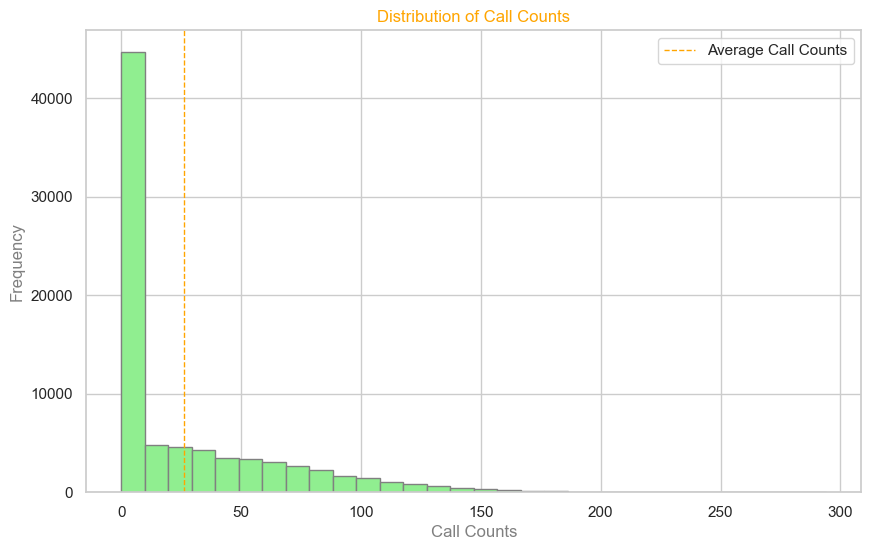

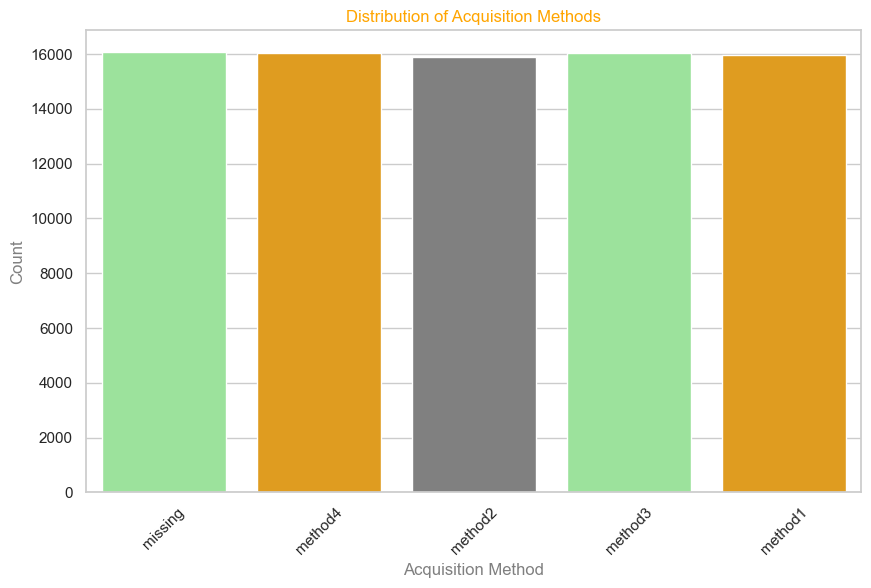

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the training data
train = pd.read_csv('train_data.csv')

# Display basic statistics for the training data
statistics = train.describe()

# Calculate average call counts
average_call_counts = train['call_counts'].mean()

# Print the statistics
print("Basic Statistics:")
print(statistics)
print("\nAverage Call Counts:", average_call_counts)

# Set up the visual style for the plots
sns.set(style='whitegrid')

# Histogram for call_counts
plt.figure(figsize=(10, 6))
plt.hist(train['call_counts'], bins=30, color='lightgreen', edgecolor='gray')
plt.title('Distribution of Call Counts', color='orange')
plt.xlabel('Call Counts', color='gray')
plt.ylabel('Frequency', color='gray')
plt.axvline(average_call_counts, color='orange', linestyle='dashed', linewidth=1, label='Average Call Counts')
plt.legend()
plt.show()

# Bar plot for a categorical variable (e.g., acq_method)
plt.figure(figsize=(10, 6))
sns.countplot(data=train, x='acq_method', palette=['lightgreen', 'orange', 'gray'])
plt.title('Distribution of Acquisition Methods', color='orange')
plt.xlabel('Acquisition Method', color='gray')
plt.ylabel('Count', color='gray')
plt.xticks(rotation=45)
plt.show()

In [9]:
import pandas as pd

# Read the training data
train = pd.read_csv('train_data.csv')

# Check for duplicates where call_counts is zero
duplicate_zeros = train[train['call_counts'] == 0].duplicated(keep=False)

# Get the rows where call_counts is zero and have duplicates
duplicates_with_zeros = train[train['call_counts'] == 0][duplicate_zeros]

# Display the duplicates with call_counts of zero
if not duplicates_with_zeros.empty:
    print("Rows with identical information and call_counts of zero:")
    print(duplicates_with_zeros)
else:
    print("No rows found with identical information and call_counts of zero.")

No rows found with identical information and call_counts of zero.


🔄 Preparing data...
🔢 Number of folds for cross-validation: 5
🚀 Training models to get feature importances...
🏆 Top 7 important features: ['call_history_squared', '12m_call_history', 'calls_per_tenure', 'premium_to_calls_ratio', 'tenure_at_snapshot', 'premium_tenure_interaction', 'ann_prm_amt']
📊 Performing cross-validation with top 7 features...
⏳ Fold 1...
⏳ Fold 2...
⏳ Fold 3...
⏳ Fold 4...
⏳ Fold 5...
⌛ Cross-validation completed in 21.63 seconds.

📈 Cross-validation RMSE scores with top 7 features: [36.021638061724325, 35.852333811004115, 36.24653317254032, 35.78786877582661, 35.81658795827111]
📊 Mean RMSE with top 7 features: 35.944992355873296
📉 Std RMSE with top 7 features: 0.17120896180349857

📈 Cross-validation R2 scores with top 7 features: [0.09449167818142379, 0.10489945773912424, 0.10323441955972623, 0.09661997679648726, 0.09531741165482399]
📊 Mean R2 with top 7 features: 0.0989125887863171
📉 Std R2 with top 7 features: 0.004295268094339464


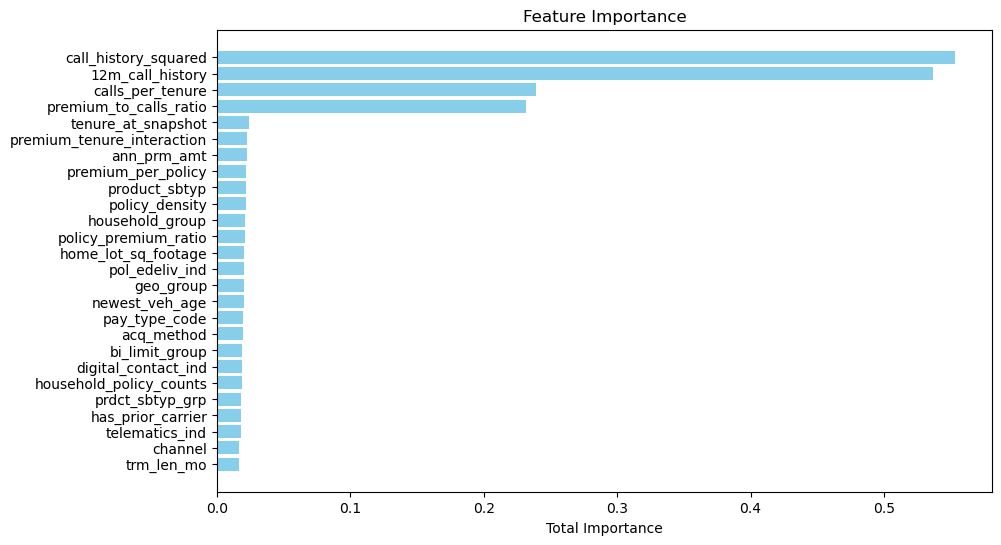

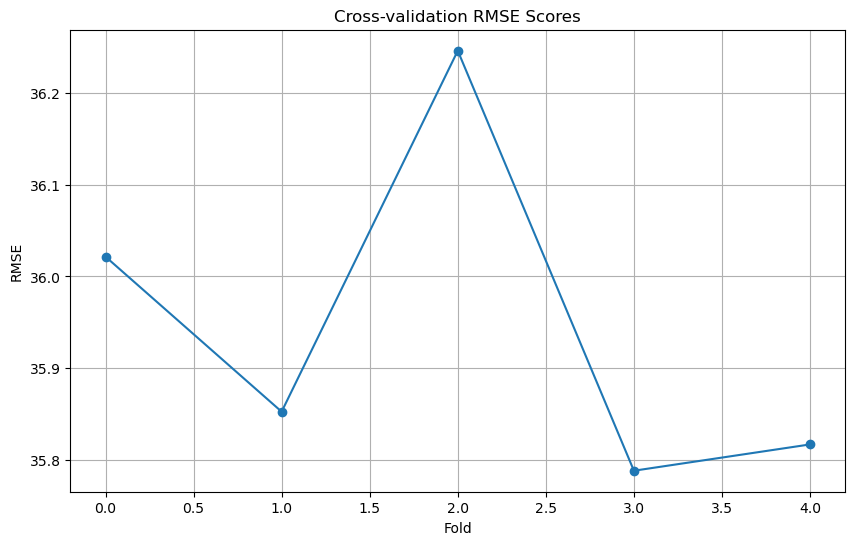

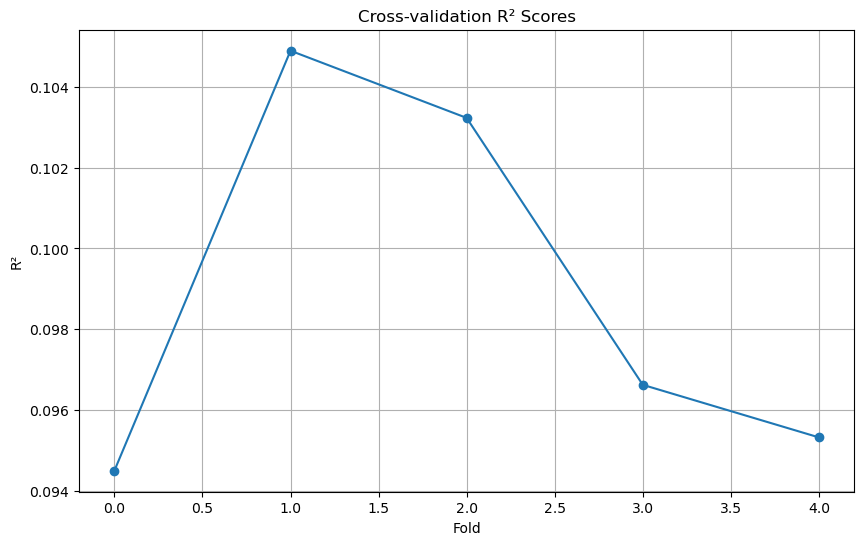

In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from math import sqrt
import time
import matplotlib.pyplot as plt

# Read the data
train = pd.read_csv('train_data.csv')
test = pd.read_csv('test_data.csv')

# Feature Engineering
def prepare_data(df):
    data = df.copy()
    
    # Handle missing values
    for col in data.columns:
        if data[col].dtype in ['int64', 'float64']:
            data[col] = data[col].fillna(data[col].median())
        else:
            data[col] = data[col].fillna(data[col].mode()[0])

    # Label encode categorical columns
    le = LabelEncoder()
    categorical_cols = ['acq_method', 'bi_limit_group', 'channel', 'geo_group',
                       'household_group', 'pay_type_code', 'prdct_sbtyp_grp', 'product_sbtyp']

    for col in categorical_cols:
        data[col] = le.fit_transform(data[col].astype(str))

    # Feature engineering
    data['premium_per_policy'] = np.where(
        data['household_policy_counts'] != 0,
        data['ann_prm_amt'] / data['household_policy_counts'],
        0
    )
    data['calls_per_tenure'] = data['12m_call_history'] / (data['tenure_at_snapshot'] + 1)
    data['premium_to_calls_ratio'] = np.where(
        data['12m_call_history'] != 0,
        data['ann_prm_amt'] / data['12m_call_history'],
        0
    )
    data['policy_density'] = data['household_policy_counts'] / (data['tenure_at_snapshot'] + 1)
    
    # Additional features for two-stage model
    data['premium_tenure_interaction'] = data['ann_prm_amt'] * data['tenure_at_snapshot']
    data['policy_premium_ratio'] = data['household_policy_counts'] * data['ann_prm_amt']
    data['call_history_squared'] = data['12m_call_history'] ** 2
    
    return data

# Prepare the data
print("🔄 Preparing data...")
train_processed = prepare_data(train)
test_processed = prepare_data(test)

# Create binary target for first stage
train_processed['is_zero'] = (train_processed['call_counts'] == 0).astype(int)

# Split features and target
X = train_processed.drop(['id', 'call_counts', 'is_zero'], axis=1)
y_binary = train_processed['is_zero']
y_regression = train_processed['call_counts']

# Define cross-validation strategy
n_folds = 5
print(f"🔢 Number of folds for cross-validation: {n_folds}")
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Parameters for binary classification (with regularization)
binary_params = {
    'objective': 'binary:logistic',
    'max_depth': 2,
    'learning_rate': 0.007,
    'n_estimators': 3000,
    'subsample': 0.50,
    'colsample_bytree': 0.50,
    'alpha': 0.01,      
    'lambda': 10.0,       
    'gamma': 0.5         
}

# Parameters for regression model (with regularization)
regression_params = {
    'objective': 'reg:squarederror',
    'max_depth': 2,
    'learning_rate': 0.001,
    'n_estimators': 6000,
    'subsample': 0.50,
    'colsample_bytree': 0.50,
    'alpha': 0.01,      
    'lambda': 10.0,       
    'gamma': 0.5         
}

# Initialize models
binary_model = xgb.XGBClassifier(**binary_params)
regression_model = xgb.XGBRegressor(**regression_params)

# Train both models on the full dataset to get feature importances
print("🚀 Training models to get feature importances...")
binary_model.fit(X, y_binary)
regression_model.fit(X, y_regression)

# Get feature importance from both models
binary_importance = pd.DataFrame({
    'feature': X.columns,
    'binary_importance': binary_model.feature_importances_
})

regression_importance = pd.DataFrame({
    'feature': X.columns,
    'regression_importance': regression_model.feature_importances_
})

# Combine feature importance
importance = binary_importance.merge(regression_importance, on='feature')
importance['total_importance'] = importance['binary_importance'] + importance['regression_importance']
importance = importance.sort_values('total_importance', ascending=False)

# Select top 7 features
top_7_features = importance['feature'].head(7).tolist()
print(f"🏆 Top 7 important features: {top_7_features}")

# Update the feature set to only the top 7 features
X_top7 = X[top_7_features]
test_top7 = test_processed[top_7_features]

# Re-run the cross-validation using only the top 7 features
cv_rmse_scores_top7 = []
cv_r2_scores_top7 = []  # New list for R2 scores
cv_predictions_top7 = np.zeros(len(test_processed))

print("📊 Performing cross-validation with top 7 features...")
start_time = time.time()
for fold, (train_idx, val_idx) in enumerate(kf.split(X_top7), 1):
    print(f"⏳ Fold {fold}...")
    
    X_train, X_val = X_top7.iloc[train_idx], X_top7.iloc[val_idx]
    y_binary_train, y_binary_val = y_binary.iloc[train_idx], y_binary.iloc[val_idx]
    y_regression_train, y_regression_val = y_regression.iloc[train_idx], y_regression.iloc[val_idx]
    
    # Train binary model
    binary_model.fit(X_train, y_binary_train)
    
    # Get binary predictions
    binary_pred_val = binary_model.predict_proba(X_val)[:, 1]
    binary_pred_test = binary_model.predict_proba(test_top7)[:, 1]
    
    # Train regression model on non-zero samples
    non_zero_mask_train = (y_regression_train > 0)
    X_train_nonzero = X_train[non_zero_mask_train]
    y_regression_train_nonzero = y_regression_train[non_zero_mask_train]
    
    regression_model.fit(X_train_nonzero, y_regression_train_nonzero)
    
    # Make regression predictions
    regression_pred_val = regression_model.predict(X_val)
    regression_pred_test = regression_model.predict(test_top7)
    
    # Combine predictions
    final_pred_val = (1 - binary_pred_val) * regression_pred_val
    final_pred_test = (1 - binary_pred_test) * regression_pred_test
    
    # Calculate RMSE and R2 for this fold
    fold_rmse_top7 = sqrt(mean_squared_error(y_regression_val, final_pred_val))
    fold_r2_top7 = r2_score(y_regression_val, final_pred_val)  # Calculate R2 score
    
    cv_rmse_scores_top7.append(fold_rmse_top7)
    cv_r2_scores_top7.append(fold_r2_top7)  # Store R2 score
    
    # Add to test predictions
    cv_predictions_top7 += final_pred_test / n_folds

end_time = time.time()
total_time = end_time - start_time
print(f"⌛ Cross-validation completed in {total_time:.2f} seconds.")

print("\n📈 Cross-validation RMSE scores with top 7 features:", cv_rmse_scores_top7)
print("📊 Mean RMSE with top 7 features:", np.mean(cv_rmse_scores_top7))
print("📉 Std RMSE with top 7 features:", np.std(cv_rmse_scores_top7))
print("\n📈 Cross-validation R2 scores with top 7 features:", cv_r2_scores_top7)
print("📊 Mean R2 with top 7 features:", np.mean(cv_r2_scores_top7))
print("📉 Std R2 with top 7 features:", np.std(cv_r2_scores_top7))

# Create a submission file using top 7 feature model
submission_top7 = pd.DataFrame({
    'id': test_processed['id'],
    'Predict': cv_predictions_top7
})

# Ensure predictions are non-negative
submission_top7['Predict'] = np.maximum(0, submission_top7['Predict'])

submission_top7.to_csv('submission_top7_features.csv', index=False)

# Plotting feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance['feature'], importance['total_importance'], color='skyblue')
plt.xlabel('Total Importance')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()

# Plotting CV RMSE scores
plt.figure(figsize=(10, 6))
plt.plot(cv_rmse_scores_top7, marker='o', linestyle='-')
plt.title('Cross-validation RMSE Scores')
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

# Plotting CV R2 scores
plt.figure(figsize=(10, 6))
plt.plot(cv_r2_scores_top7, marker='o', linestyle='-')
plt.title('Cross-validation R² Scores')
plt.xlabel('Fold')
plt.ylabel('R²')
plt.grid(True)
plt.show()